# text

> The text application: ModernBERT-large by default, a frozen encoder with cached anchor vectors by default, and the reproduction of Laya's fine-tune.

In [ ]:
#| default_exp text

In [ ]:
#| export
from sysone.core import *
from sysone.template import *
from sysone.data import TypedDecisions, RowSampler, Shortlist
from sysone.models import *
from sysone.learner import Learner, PRESETS
from sysone.learner import decision_learner as _decision_learner
from sysone.inference import Decider
from sysone.cache import FeatureCache        # and the verbs the cache adds to Learner, `fit_linear` among them

In [ ]:
#| hide
from fastcore.test import test_eq, test_close, test_fail
import json, logging, subprocess, sys, tempfile, torch
from pathlib import Path
logging.getLogger("transformers").setLevel(logging.ERROR)
import datasets, transformers; datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
                     "axes.titlesize": 9, "legend.fontsize": 8, "legend.frameon": False})

The application layer only chooses defaults; every layer below stays reachable. For text that means ModernBERT-large as the encoder, Laya's row template, and the cheap experiment as the default path: with `train="head"` the encoder is frozen and runs once to fill a cache of anchor vectors, and the head (Laya's scorer, without layers) trains from the cache in seconds. `lora`, `mica` and `full` are one argument away, and drop the cache.

In [ ]:
#| export
ENCODER = "answerdotai/ModernBERT-large"
MULTILINGUAL = "jhu-clsp/mmBERT-base"

def decision_learner(data:TypedDecisions, encoder:str=ENCODER, train="head", cache="auto", head:str|None=None, **kw) -> Learner:
    "A text `Learner`: ModernBERT-large, and with `train='head'` a frozen encoder training from cached anchor vectors"
    if cache == "auto": cache = "masks" if train == "head" and head in (None, "mlp", "linear") and not kw.get("head_layers") else None
    head = head or ("mlp" if cache == "masks" else "laya")
    return _decision_learner(data, encoder, train=train, cache=cache, head=head, **kw)

In [ ]:
fresh = subprocess.run([sys.executable, "-c", "import sysone.text, sysone.learner as L; print(hasattr(L.Learner, 'fit_linear'))"],
                       capture_output=True, text=True)
test_eq(fresh.stdout.strip(), "True")      # in a fresh session the application brings the cache's verbs, fit_linear among them

The ten lines, on the fixtures (the real encoder and data are one string each away; see below):

In [ ]:
data  = TypedDecisions.from_json("fixtures/typed_decisions_tiny.jsonl", valid=0.25, calib=0.25)
learn = decision_learner(data, "fixtures/tiny-modernbert", train="head", preset="cpu", cache_dir=tempfile.mkdtemp())
learn.lr_find(steps=30)
learn.fit_one_cycle(4, lr=3e-3)
learn.calibrate(min_rows=4)
rec = data.cases["valid"][0]; state, questions = load_record(rec)["state"], load_record(rec)["questions"]
answers = learn.predict(state, questions)
path = learn.export(Path(tempfile.mkdtemp()) / "my-jev")
jev = Decider.load(path, device="cpu")
jev.predict(state, questions)

{'loss': '0.7918', 'grad_norm': '0.004856', 'learning_rate': '1e-07', 'epoch': '0.1429'}
{'loss': '1.227', 'grad_norm': '0.003278', 'learning_rate': '1.743e-07', 'epoch': '0.2857'}
{'loss': '1.409', 'grad_norm': '0.001284', 'learning_rate': '3.039e-07', 'epoch': '0.4286'}
{'loss': '0.3029', 'grad_norm': '0.001855', 'learning_rate': '5.298e-07', 'epoch': '0.5714'}
{'loss': '1.244', 'grad_norm': '0.002457', 'learning_rate': '9.237e-07', 'epoch': '0.7143'}
{'loss': '1.142', 'grad_norm': '0.004998', 'learning_rate': '1.61e-06', 'epoch': '0.8571'}
{'loss': '0.5806', 'grad_norm': '0.003068', 'learning_rate': '2.807e-06', 'epoch': '1'}
{'loss': '1.106', 'grad_norm': '0.004495', 'learning_rate': '4.894e-06', 'epoch': '1.143'}
{'loss': '0.8423', 'grad_norm': '0.005702', 'learning_rate': '8.532e-06', 'epoch': '1.286'}
{'loss': '0.9464', 'grad_norm': '0.004038', 'learning_rate': '1.487e-05', 'epoch': '1.429'}
{'loss': '1.196', 'grad_norm': '0.002436', 'learning_rate': '2.593e-05', 'epoch': '1.571

{'action': {'type': 'choice',
  'choice': 'continue',
  'probabilities': {'continue': 0.25,
   'human_review': 0.25,
   'observe': 0.25,
   'stop': 0.25},
  'confidence': 0.0,
  'answer_confidence': 0.25},
 'needs_review': {'type': 'noul',
  'noul': 0.5,
  'confidence': 0.5,
  'answer_confidence': 0.5},
 'outcome': {'type': 'choice',
  'choice': 'success',
  'probabilities': {'failure': 0.25,
   'harmful': 0.25,
   'partial': 0.25,
   'success': 0.2501},
  'confidence': 0.0,
  'answer_confidence': 0.2501},
 'risk': {'type': 'score',
  'score': 1.5003,
  'legend': {'0': 'Benign: read-only or clearly safe actions.',
   '1': 'Low: routine writes within scope.',
   '2': 'Moderate: irreversible or out-of-scope actions.',
   '3': 'High: destructive, security-relevant, or policy-violating actions.'},
  'probabilities': {'0': 0.2499, '1': 0.2499, '2': 0.2501, '3': 0.2501},
  'confidence': 0.0,
  'answer_confidence': 0.2501},
 'urgency': {'type': 'score',
  'score': 1.5005,
  'legend': {'0': 'N

In [ ]:
test_eq((learn.cache, learn.model.head.layers, learn.model.regime), ("masks", 0, "head"))
test_eq(jev.predict(state, questions), answers)
test_eq(decision_learner(data, "fixtures/tiny-modernbert", train="lora", preset="cpu").cache, None)

## Typed-decisions on ModernBERT-large

The same lines on the real data and encoder, run on the M3 Pro this library targets for laptop experiments (MPS, fp32). The encoder is frozen: it runs once over the 6,000 training rows and the held-out rows to fill the cache, then the scorer trains from the cached anchors.

In [ ]:
#| eval: false
data  = TypedDecisions.from_hub("LocalLLaMA/typed-decisions", valid="test")
learn = decision_learner(data, "answerdotai/ModernBERT-large", train="head")   # frozen encoder, cached features
sugg  = learn.lr_find()
learn.fit_one_cycle(4, lr=sugg.valley)
learn.calibrate()
learn.validate()

The run, pasted (2026-09-26, M3 Pro, MPS, fp32):

```
SuggestedLRs(valley=1.48e-03, steep=1.00e-07)
cache: 5,400 train + 2,000 test + 600 calib rows encoded once in 656 s; 44 MB of anchors for the training rows
fit_one_cycle(4): 58 s

epoch  valid loss  accuracy  brier   ece    kl     score MAE
1      1.143       0.442     0.192   0.044  0.333  0.682
2      1.125       0.449     0.206   0.059  0.347  0.616
3      1.110       0.487     0.192   0.070  0.328  0.597
4      1.096       0.504     0.187   0.037  0.318  0.576

temperatures: choice 0.97, score 1.17, noul 1.53
validate(): accuracy 0.504 (choice 0.445, score 0.446, noul 0.640), soft accuracy 0.429, Brier 0.186, KL 0.315,
            ECE 0.049, score MAE 0.58, within one level 0.82
```

Twelve minutes end to end, of which the head's training is one: the laptop path works, and the encoder pass dominates. The number is the lesson the design expected: 0.504 is above the card's prior (0.470, a model that ignores the input) but below its majority baseline (0.520, always the commonest label), because the `[MASK]` vectors of an encoder never tuned for decisions carry little of the task. The regimes that train the encoder are one argument away, and a decision-tuned encoder (Laya's, GLiNER2.5-Decide's) is the stronger frozen backbone.

### Regimes on the laptop

The same measurement for Laya's checkpoints, scored with `sysone.evaluate` on the same 2,000 test decisions (M3 Pro, MPS, fp32, 2026-09-26). Laya's general English checkpoint answers these workflows poorly zero-shot, below the card's prior; its encoder, frozen, is a better backbone for a new head than ModernBERT-large's; and the gap to Laya's fine-tuned checkpoint is what training the encoder buys.

| Encoder | Regime | Accuracy | Brier | ECE | Time |
| --- | --- | --- | --- | --- | --- |
| Laya's general checkpoint (`convaiinnovations/laya`) | zero-shot, its own head | 0.362 | 0.329 | 0.175 | 3 min to score |
| ModernBERT-large, frozen | head only, cached anchors | 0.504 | 0.186 | 0.049 | 11 min cache + 1 min training |
| Laya's general encoder, frozen | head only, cached anchors | 0.560 | 0.153 | 0.067 | 10 min cache + 1 min training |
| Laya's typed-decisions checkpoint | fine-tuned by Laya's notebook | 0.766 | 0.066 | 0.213 | 3 min to score |

The frozen Laya encoder was trained with `decision_learner(data, "convaiinnovations/laya", train="head")`, lr_find's valley (5.7e-5), `fit_one_cycle(4)`, and calibrated temperatures; LoRA and full fine-tuning of ModernBERT-large on this machine take hours, and are the cloud notebook's job.

The four runs against the dataset card's two landmarks, the majority baseline (the floor) and the teacher's agreement with itself (where the labels stop being able to tell models apart):

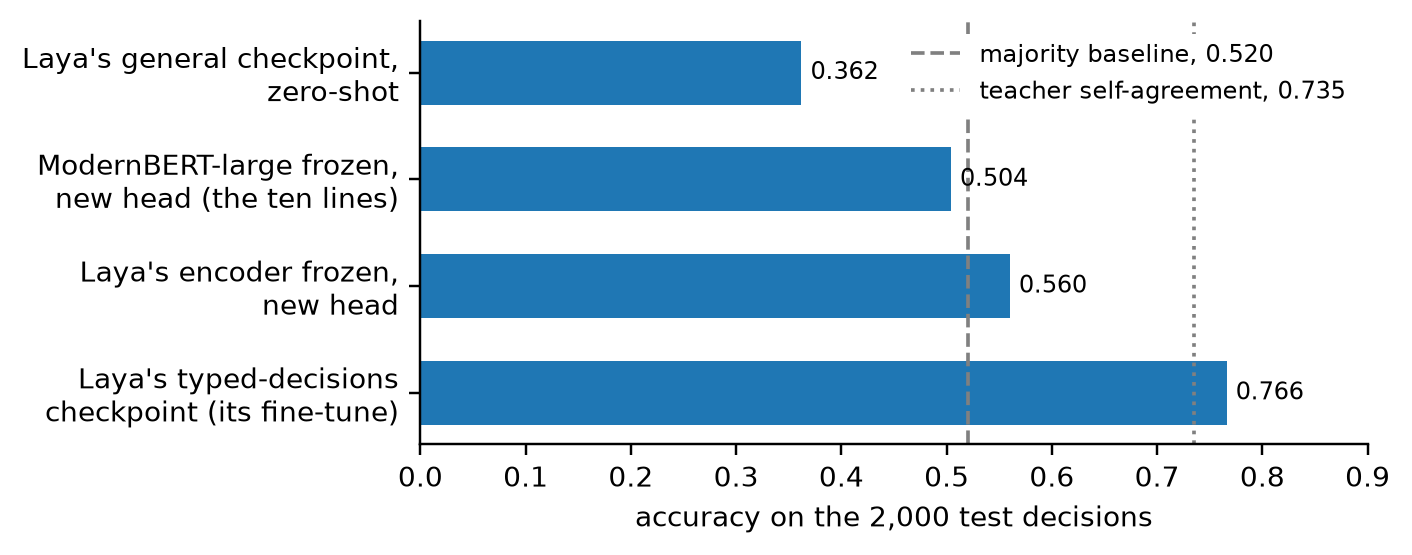

In [ ]:
#| code-fold: true
#| code-summary: figure code
runs = {"Laya's general checkpoint,\nzero-shot": 0.362, "ModernBERT-large frozen,\nnew head (the ten lines)": 0.504,
        "Laya's encoder frozen,\nnew head": 0.560, "Laya's typed-decisions\ncheckpoint (its fine-tune)": 0.766}
fig, ax = plt.subplots(figsize=(6.5, 2.6))
bars = ax.barh(list(runs)[::-1], list(runs.values())[::-1], color="C0", height=0.6)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
for x, name, ls in ((0.52, "majority baseline, 0.520", "--"), (0.735, "teacher self-agreement, 0.735", ":")):
    ax.axvline(x, color="gray", ls=ls, lw=1.2, label=name)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", framealpha=1); ax.set_xlim(0, 0.9); ax.set_xlabel("accuracy on the 2,000 test decisions"); plt.tight_layout(); plt.show()

## Reproducing Laya's fine-tune

Laya's notebook fine-tunes the released checkpoint, encoder and head, on the typed-decisions training split: 4 epochs, micro-batch 8 × accumulation 4 × 2 T4 GPUs, learning rates 2.5e-5 for the encoder and 1e-4 for the head, a cosine schedule, RLCD with σ from 0.4 to 0.1 and a group of 4, and temperatures fitted on a held-out slice; it reports 0.766 accuracy on the 2,000 test decisions. In sysone that is a Laya checkpoint as the encoder source, its head as the warm start, the `full` regime and the `t4x2` preset, launched with `torchrun --nproc_per_node=2` (or `sysone run --on kaggle`, see the cloud notebook). The notebook trains on rows built with the checkpoint's budgets (512 / 192) and evaluates with 1,024 / 256; the export below does the same.

In [ ]:
#| eval: false
data  = TypedDecisions.from_hub("LocalLLaMA/typed-decisions", valid="test")
learn = decision_learner(data, "convaiinnovations/laya", init_from="convaiinnovations/laya", train="full",
                         loss="rlcd", preset="t4x2", lr=(2.5e-5, 1e-4))
learn.fit_one_cycle(4, pct_start=0.0)          # cosine, no warmup, as the notebook's CosineAnnealingLR
learn.calibrate()
learn.data.bind(learn.data.builder.tok, learn.data.builder.template.replace(max_len=1024, head_max_len=256))
learn.export("laya-typed-decisions")           # sysone.json + the Laya format

from sysone.evaluate import typed_decisions_report
typed_decisions_report(Decider.load("laya-typed-decisions"))

## Other text encoders

Any encoder whose tokenizer defines cls, sep and mask gets Laya's row through the `auto` template; known families ship their own. mmBERT, Laya's multilingual backbone, is a ModernBERT and uses the `laya` template unchanged:

In [ ]:
#| eval: false
learn = decision_learner(data, MULTILINGUAL, train="lora", preset="t4")

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()